In [252]:
import os
import re


from collections import Counter
from collections import defaultdict
import copy


import numpy as np
import pandas as pd
from IPython.display import display
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

In [253]:
data = pd.read_csv(r'Запчасти списанные в ремонт.csv', skiprows=[0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=str)
data = data[data['Номенклатура.Артикул'].notna()]
data = data.drop(columns=['Unnamed: 1', 'Unnamed: 5', 'Unnamed: 6'])
data = data.iloc[:-1].reset_index(drop=True)
data = data[~(data['Номенклатура.Оригинальный номер'].isna() & data['Номенклатура.Артикул'].isna())]

conditions1 = [
    data['Машина'].str.contains('ножничный', case=False, na=False),
    data['Машина'].str.contains('коленчатый', case=False, na=False),
    data['Машина'].str.contains('телескопический', case=False, na=False),
    data['Машина'].str.contains('мачтовый', case=False, na=False)
]

choices1 = ['ножничный', 'коленчатый', 'телескопический', 'мачтовый']

data['Тип подъемника'] = np.select(conditions1, choices1, default='другое')

conditions2 = [

    data['Машина'].str.contains('электрический', case=False, na=False),
    data['Машина'].str.contains('дизельный', case=False, na=False),
]

choices2 = ['Электрический', 'Дизельный']

data['Тип двигателя'] = np.select(conditions2, choices2, default='другое')

data = data.loc[~(data['Тип подъемника'] == 'другое')]

data = data[~(data['Машина'].str.startswith("Телескопический погрузчик"))]

data.loc[data['Машина'] == 'Телескопический подъемник Zoomlion ZT72J-V', 'Тип двигателя'] = 'Дизельный'
data.loc[data['Машина'] == 'Телескопический подъемник Zoomlion ZT30J', 'Тип двигателя'] = 'Дизельный'

data['Дата'] = pd.to_datetime(data['Дата'], format='%d.%m.%Y %H:%M:%S')
data['Год'] = data['Дата'].dt.year
data['Квартал'] = data['Дата'].dt.quarter
data['Лот.CRM год выпуска'] = data['Лот.CRM год выпуска'].apply(lambda x: x.replace(',', '.') if isinstance(x, str) else x)
data['Лот.CRM наработка'] = data['Лот.CRM наработка'].apply(lambda x: x.replace(',', '.') if isinstance(x, str) else x)

col = data.pop("Квартал")  
data.insert(2, "Квартал", col)

data2 = pd.read_excel('Остатки и обороты.xls', skiprows=[0, 1, 2, 3, 4, 5, 6, 7], dtype=str)

In [254]:
df1 = copy.deepcopy(data)
df2 = copy.deepcopy(data2)

In [255]:
df1.loc[df1['Номенклатура.Оригинальный номер расширенный'] == 'HH1C032430  1C01032432  P550318 1009901968 1C020-32434-P   1C02032434  HLX-6995 Engine Oil Filter Replaces P550318 LF3376 807180 15056-32432 16098-31291 1C020-32430 1C020-32432 1C020-32433 1C020-32434 279809 4042216 582018366 HH1C0-32430 15521-32439 HLX Haolixin HLX Haolixin HLX-6995 Engine Oil Filter Replaces P550318 LF3376 807180 15056-32432 16098-31291 || 1C020-32430 1C020-32432 1C020-32433 1C020-32434 279809 4042216 582018366 HH1C0-32430 15521-32439 ', 'Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура.Оригинальный номер расширенный'] == 'JCPT1412HA','Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура.Оригинальный номер расширенный'] == 'AMWP11.5-8100','Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура.Оригинальный номер расширенный'] == 'ZS1212','Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура.Артикул'] == 'DIFA438201', 'Номенклатура.Оригинальный номер расширенный'] = 'DIFA 4382-01'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный 32925682', 'Номенклатура.Оригинальный номер расширенный'] = '32/925682 AF26656'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный 32925682', 'Номенклатура.Оригинальный номер'] = '32/925682'
df1.loc[df1['Номенклатура'] == 'НПУ 00007940', 'Номенклатура.Артикул'] = '85000159'
df1.loc[df1['Номенклатура'] == 'НПУ 00007940', 'Номенклатура.Оригинальный номер'] = '85000159'
df1.loc[df1['Номенклатура'] == 'НПУ 00007940', 'Номенклатура.Оригинальный номер расширенный'] = '85000159'
df1.loc[df1['Номенклатура'] == 'Цилиндр поворота платформы 1010201914', 'Номенклатура.Оригинальный номер'] = '1010201914'
df1.loc[df1['Номенклатура'] == 'Трос аварийного опускания Haulotte Compact', 'Номенклатура.Оригинальный номер'] = '2420314420'
df1.loc[df1['Номенклатура'] == 'Трос аварийного опускания Haulotte Compact', 'Номенклатура.Оригинальный номер расширенный'] = '2326009100'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный 90031461A', 'Номенклатура.Оригинальный номер расширенный'] = '43121'
df1.loc[df1['Номенклатура'] == 'Фильтр масляный C-7926', 'Номенклатура.Оригинальный номер расширенный'] = '1009900560'
df1.loc[df1['Номенклатура'] == 'Датчик 203150000055', 'Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура'] == 'Фильтр топливный Yanmar DF-5543', 'Номенклатура.Оригинальный номер расширенный'] = '201990003015 60356164 7029012 A977950 MIU802421 SF-52010 SF52010 SK48584 SN25127 XJAU01355 XJAU01515 YM129A0055730'
df1.loc[df1['Номенклатура'] == 'Клапан балансировочный поворотного редуктора корзины 1019901661', 'Номенклатура.Оригинальный номер расширенный'] = '1010201471 1010202355 1010202356 ls2-009-180qmajc'
df1.loc[df1['Номенклатура'] == 'Фильтр гидравлический в сборе 00001871', 'Номенклатура.Оригинальный номер расширенный'] = '00004696 0160D010BN3HC SH75028'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный A8506S', 'Номенклатура.Оригинальный номер расширенный'] = '1000100310 P827653 RF3091AB ST40706'
df1.loc[df1['Номенклатура'] == 'Фильтр топливный SFC7945002', 'Номенклатура.Оригинальный номер расширенный'] = '1010601542 SFC-79450-02 SFC7945002 SK3170 ST20094'
df1.loc[df1['Номенклатура'] == 'Фильтр гидравлический CS05030P10A', 'Номенклатура.Оригинальный номер расширенный'] = '202080000036 SH56560 SP-06X10G3 SPF-53 SPF-538-100 stx202027'
df1.loc[df1['Номенклатура'] == 'Элемент фильтра гидравлического 00004416', 'Номенклатура.Оригинальный номер расширенный'] = '00003113 00004416'
df1.loc[df1['Номенклатура'] == 'Стартер Kubota 2403 TT15790', 'Номенклатура.Оригинальный номер расширенный'] = '17123-6301-6 17123-63017 1712363016 1712363017 CPK00215'
df1.loc[df1['Номенклатура'] == 'Фильтр топливный FS36209', 'Номенклатура.Оригинальный номер расширенный'] = '1000000876 201990000029'
df1.loc[df1['Номенклатура'] == 'Фильтр топливный ГО BA16-22CRT 10003966A (Kubota)', 'Номенклатура.Оригинальный номер расширенный'] = '1g311-43380 1g31143380 8972133810 FF5468 PF9873 SK3686 SN21586'
df1.loc[df1['Номенклатура'] == 'Фильтр топливный GB6245', 'Номенклатура.Оригинальный номер расширенный'] = '1000700908 PL420 ST21350'
df1.loc[df1['Номенклатура'] == 'Фильтр масляный MANN-W 814/80', 'Номенклатура.Оригинальный номер расширенный'] = '11923630 199100323 2151740 2151740 749613 HH164-32430'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный DIFA 43121', 'Номенклатура.Оригинальный номер расширенный'] = '90029290 90031461A AF26656 P608533 P609490 ST40110 Z32540'
df1.loc[df1['Номенклатура'] == 'Фильтр гидравлический R0110A10NHA', 'Номенклатура.Оригинальный номер расширенный'] = 'LH0110R010BN/HC DH3723 RHR110G10B3/AB1 P170604'
df1.loc[df1['Номенклатура'] == 'ЭБУ 203020000001', 'Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура'] == 'Зарядное устройство 2029900000311', 'Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура'] == 'Насос гидравлический 81013GT', 'Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура'] == 'Фильтрующий элемент очистки воздуха (внутренний) 4382-01', 'Номенклатура.Оригинальный номер расширенный'] = 'DIFA 4382-01'
df1.loc[df1['Номенклатура'] == 'Фильтрующий элемент очистки воздуха (внутренний) 4382-01', 'Номенклатура.Артикул'] = 'DIFA 4382-01'
df1.loc[df1['Номенклатура'] == 'Замок зажигания 90173', 'Номенклатура.Оригинальный номер расширенный'] = '84830'

df1.loc[df1['Номенклатура'] == 'Фильтр гидравлический RHR110G10B3/AB1', 'Номенклатура.Оригинальный номер расширенный'] = '(LH)0110A10BN/HA(HC) 0110R010BN3HC KFSF-0110-R-010-N R0110 R0110A010NHA R0110A10NHA'

df1.loc[df1['Номенклатура'] == 'Фильтр воздушный Z32540', 'Номенклатура.Оригинальный номер'] = '90029290'

df1.loc[df1['Номенклатура'] == 'Фильтрующий элемент очистки воздуха (внешний) 4382', 'Номенклатура.Оригинальный номер расширенный'] = np.nan

df1.loc[df1['Номенклатура'] == 'Фильтр воздушный внутренний P829333', 'Номенклатура.Оригинальный номер расширенный'] = '216070000008 4383-01'

df1.loc[df1['Номенклатура'] == 'Фильтр воздушный внешний P828889', 'Номенклатура.Оригинальный номер расширенный'] = '216070000004 4383'

df1.loc[df1['Номенклатура'] == 'Фильтр масляный C1110', 'Номенклатура.Оригинальный номер расширенный'] = '90024289 SO228 C-1405 LS32665 01174416'

df1.loc[df1['Номенклатура'] == 'Фильтр воздушный комплект p828889', 'Номенклатура.Оригинальный номер расширенный'] = '216070000004 4383'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный комплект p828889', 'Номенклатура.Оригинальный номер'] = '00006753'

df1.loc[df1['Номенклатура'] == 'Фильтр гидравлический D0110A10NHA', 'Номенклатура.Оригинальный номер расширенный'] = '00004697 D0110A10NHA LH0110D010BN3HC'

df1.loc[df1['Номенклатура'] == 'Фильтр воздушный DIFA 43121-01', 'Номенклатура.Артикул'] = 'DIFA 43121-01'
df1.loc[df1['Номенклатура.Артикул'] == '438201', 'Номенклатура.Артикул'] = '4382-01'

df1.loc[df1['Номенклатура'] == 'Фара 00006753A/00005190A', 'Номенклатура.Аритикул'] = '00006753'
df1.loc[df1['Номенклатура'] == 'Фара 00006753A/00005190A', 'Номенклатура'] = 'Фара головного света 00006753'

cols = [
    'Номенклатура.Артикул',
    'Номенклатура.Оригинальный номер',
    'Номенклатура.Оригинальный номер расширенный'
]

df1[cols] = df1[cols].replace(r'DIFA\s*', '', regex=True)

df1[cols] = df1[cols].replace(r'\s+', ' ', regex=True).apply(lambda x: x.str.strip())

mask_plus = (
    df1['Номенклатура'].str.contains(r'\+', na=False) &
    ~df1['Номенклатура'].str.contains(r'^(?:Колесо|РВД|[Оо]богреватель)', na=False)
)

mask_st_units = df1['Номенклатура'].str.contains(
    r'Фильтр воздушный ST40111/40110',
    case=False,
    na=False
)

mask_brackets = df1['Номенклатура'].str.contains(
    r'(95*165*340/70*90*335,',
    case=False,
    na=False,
    regex=False
)

mask_kt = df1['Номенклатура'].str.contains(
    r'Фильтр воздушный AF26656 к-т',
    case=False,
    na=False,
)

mask_AB = df1['Номенклатура'].str.contains(
    r'Фильтр воздушный ST40131AB',
    case=False,
    na=False,
)

mask_hid = df1['Номенклатура'].str.contains(
    r'Фильтр воздушный ST40111ST40110',
    case=False,
    na=False,
)

complects = df1[mask_plus | mask_st_units | mask_brackets | mask_kt | mask_AB | mask_hid]
complects.loc[complects['Номенклатура'] == 'Фильтр воздушный AF26656 к-т', 'Номенклатура'] = 'Фильтр воздушный к-т AF26656+AF26655'
complects.loc[complects['Номенклатура'] == 'Фильтр воздушный ST40131AB', 'Номенклатура'] = 'Фильтр воздушный (95*165*340/70*90*335, сдвоенный) kw1634'

df1 = df1[~df1.index.isin(complects.index)]


In [256]:
matches = {
    '43121': '90029290 90031461A AF26656 P608533 P609490 ST40110 Z32540', # внешниий
    '43121-01': '90031459 P600975 Z32603', # внутренний
    '4382': '1000100310 P827653', # внешниий
    '4382-01': '1000100311 P829332', # внутренний
    'kw1634': '201020003059', # внешниий
    'kw1634in': '201020003058', # внутренний
    'AF26656': '32/925682 ST40110', # внешниий
    'AF26655': '32/925683 ST40111', # внутренний
    'ST40110': '90031461 AF26656', # внешний
    'ST40111': '90031459 AF26655', # внутренний
    '4383': '216070000004 P828889', # внешниий
    '4383-01': '216070000008 P829333', # внутренний
    'AF2555': '1000100310 6666375 B222100000593', # внешниий
    'AF25484': '1000100311 6666376 B222100000591' # внутренний
}


def extract_articles(text, match_keys):

    text = re.sub(r'([A-Za-z]+)(\d+)/(\d+)', r'\1\2 \1\3', text)

    if 'kw1634' in text and 'сдвоенный' in text:
        return ['kw1634in', 'kw1634'] 
    found = []
    for key in match_keys:
        pattern = re.escape(key)
        if re.search(pattern, text):
            found.append(key)
    return found

# Применяем функцию
complects['Номенклатура.Артикул'] = complects['Номенклатура'].apply(lambda x: extract_articles(x, matches.keys()))

# Explode → по одной запчасти на строку
df_exploded = complects.explode('Номенклатура.Артикул').reset_index(drop=True)

# Подставляем оригинальный номер из словаря
df_exploded['Номенклатура.Оригинальный номер'] = df_exploded['Номенклатура.Артикул'].map(lambda x: matches[x].split()[0] if x in matches else None)
df_exploded['Номенклатура.Оригинальный номер расширенный'] = df_exploded['Номенклатура.Артикул'].map(matches)

assert (df_exploded.shape[0] == complects.shape[0] * 2)

# Объединяем DataFrame'ы
df1 = pd.concat([df1, df_exploded], ignore_index=True)

# Если есть колонка с датой, сортируем по ней
df1 = df1.sort_values(by='Дата', ignore_index=True)

In [257]:
def add_original_to_extended(row):
    main_art = str(row["Номенклатура.Артикул"]).strip()
    extended = row["Номенклатура.Оригинальный номер расширенный"]
    original = row["Номенклатура.Оригинальный номер"]

    extended_parts = []
    if pd.notna(extended) and str(extended).strip() != "":
        extended_parts = re.split(r'\s+', str(extended))
        extended_parts = [part.strip() for part in extended_parts if part.strip()]
        

    original_parts = []
    if pd.notna(original) and str(original).strip() != "":
        original_parts = [str(original).strip()]

    extended_upper = [p.upper() for p in extended_parts]

    for part in original_parts:
        if part.upper() not in extended_upper and part.upper() != main_art.upper():
            extended_parts.append(part)

    extended_parts = sorted(list(dict.fromkeys(extended_parts)))

    return " ".join(extended_parts) if extended_parts else np.nan

df1["Номенклатура.Оригинальный номер расширенный"] = df1.apply(add_original_to_extended, axis=1) 

In [258]:
df1['Аналоги'] = (
    df1['Номенклатура.Оригинальный номер расширенный']
    .fillna('')         
    .str.upper()
    .str.split()
)
graph = defaultdict(set)

for _, row in df1.iterrows():
    part = row['Номенклатура.Артикул']
    
    for analog in row['Аналоги']:
        if analog != part: 
            graph[part].add(analog)
            graph[analog].add(part)

def find_all_analogs(start, graph):
    
    visited = set()
    stack = [start]
    
    while stack:
        node = stack.pop()
        
        if node not in visited:
            visited.add(node)
            stack.extend(graph[node] - visited)
    
    # visited.remove(start)
    
    return visited

df1['all_analogs'] = df1['Номенклатура.Артикул'].apply(lambda x: find_all_analogs(x, graph))
df1['all_analogs'] = df1['all_analogs'].apply(lambda x: tuple(sorted(x)))
df1 = df1.drop(columns='Аналоги')

group_mapping = {}
group_counter = 1

for group_tuple in df1['all_analogs'].unique():
    group_mapping[group_tuple] = group_counter
    group_counter += 1

df1['Номер группы'] = df1['all_analogs'].map(group_mapping)

In [259]:
df1.to_excel('text.xlsx', index=False)

In [260]:
for i in range(0, 1000):
    group_rows = df1.loc[df1['Номер группы'] == i]
    
    if not group_rows.empty:
        # Берём размер группы через первый элемент all_analogs
        group_size = len(group_rows.iloc[0]['all_analogs'])
        
        if group_size > 2:
            display(group_rows[['Номенклатура', 'Номенклатура.Артикул', 'all_analogs']].value_counts())

Номенклатура                            Номенклатура.Артикул  all_analogs                            
Разъем НПУ в сборе с проводом Zoomlion  Я0378323              (12.02.000009, Z12.02.000009, Я0378323)    131
Name: count, dtype: int64

Номенклатура                             Номенклатура.Артикул  all_analogs                            
Разъем ВПУ  в сборе с проводом Zoomlion  Я0378316              (12.02.000010, Z12.02.000010, Я0378316)    121
Разъем ВПУ (папа)                        Я0378316              (12.02.000010, Z12.02.000010, Я0378316)     14
Name: count, dtype: int64

Номенклатура          Номенклатура.Артикул  all_analogs                            
Кнопка Стоп 122514GT  122514GT              (122514GT, 26.01.000002, Y26.01.000002)    281
Name: count, dtype: int64

Номенклатура                                                      Номенклатура.Артикул  all_analogs                                                                                                          
Замок зажигания с ключом 84830 ZOOMLION                           84830                 (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 89943-29, 90173, IHP-30, Y26.01.000023, Y26.01.000024)    279
Замок зажигания с ключом 84830/90173  4130000723001 LGMG          4130000723001         (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 89943-29, 90173, IHP-30, Y26.01.000023, Y26.01.000024)    246
Замок зажигания с ключом IHP-30 (1020520943) 1020521389 ZOOMLION  1020521389            (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 89943-29, 90173, IHP-30, Y26.01.000023, Y26.01.000024)    222
Замок зажигания 90173                                             90173                 (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 8994

Номенклатура                 Номенклатура.Артикул  all_analogs                                                     
Кнопка "Масса" 26.01.000003  26.01.000003          (00000655, 26.01.000003, 4130001123, DL-00000655, Y26.01.000003)    23
Кнопка "Масса" 4130001123    4130001123            (00000655, 26.01.000003, 4130001123, DL-00000655, Y26.01.000003)     9
Контактор 00000655           00000655              (00000655, 26.01.000003, 4130001123, DL-00000655, Y26.01.000003)     1
Name: count, dtype: int64

...

Номенклатура                   Номенклатура.Артикул  all_analogs                  
Насос подкачки Deutz 04128101  04128101              (04128101, 90029469, kr0032p)    2
Бензонасос электрический       kr0032p               (04128101, 90029469, kr0032p)    1
Name: count, dtype: int64

Номенклатура              Номенклатура.Артикул  all_analogs                       
Фильтр топливный FC-1804  FC-1804               (4110001811373, FC-1804, FK28316K)    1
Name: count, dtype: int64

Номенклатура            Номенклатура.Артикул  all_analogs                         
Стартер Yanmar TT16046  TT16046               (129136-77011, 12913677011, TT16046)    1
Name: count, dtype: int64

Номенклатура                                       Номенклатура.Артикул  all_analogs                                                                      
Фильтр топливный ГО BA16-22CRT 10003966A (Kubota)  10003966A             (10003966A, 1G311-43380, 1G31143380, 8972133810, FF5468, PF9873, SK3686, SN21586)    2
Name: count, dtype: int64

Номенклатура                                         Номенклатура.Артикул  all_analogs                        
Блок управления JLG 600S, 600AJ, 800S, 800AJ, 740AJ  Я0387359              (10011036577, 1001103667, Я0387359)    1
Name: count, dtype: int64

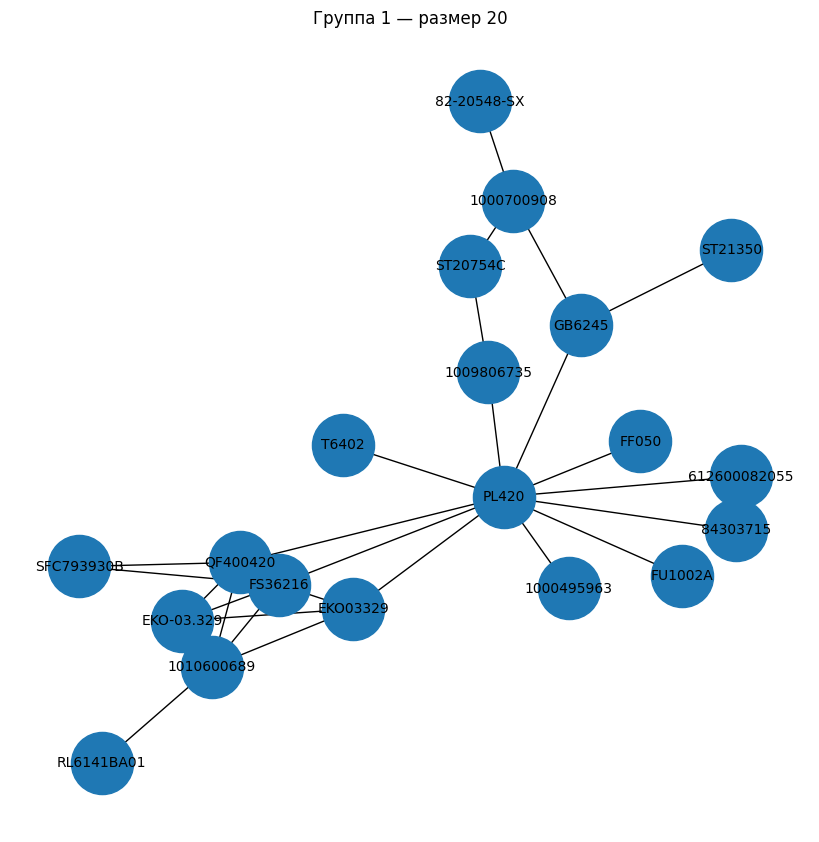

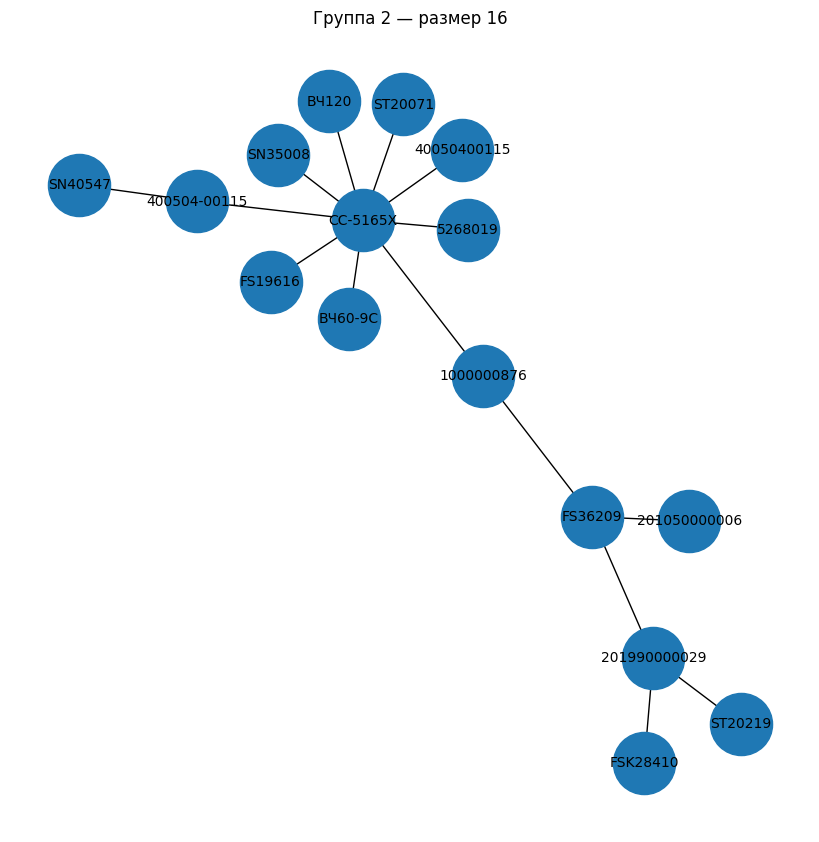

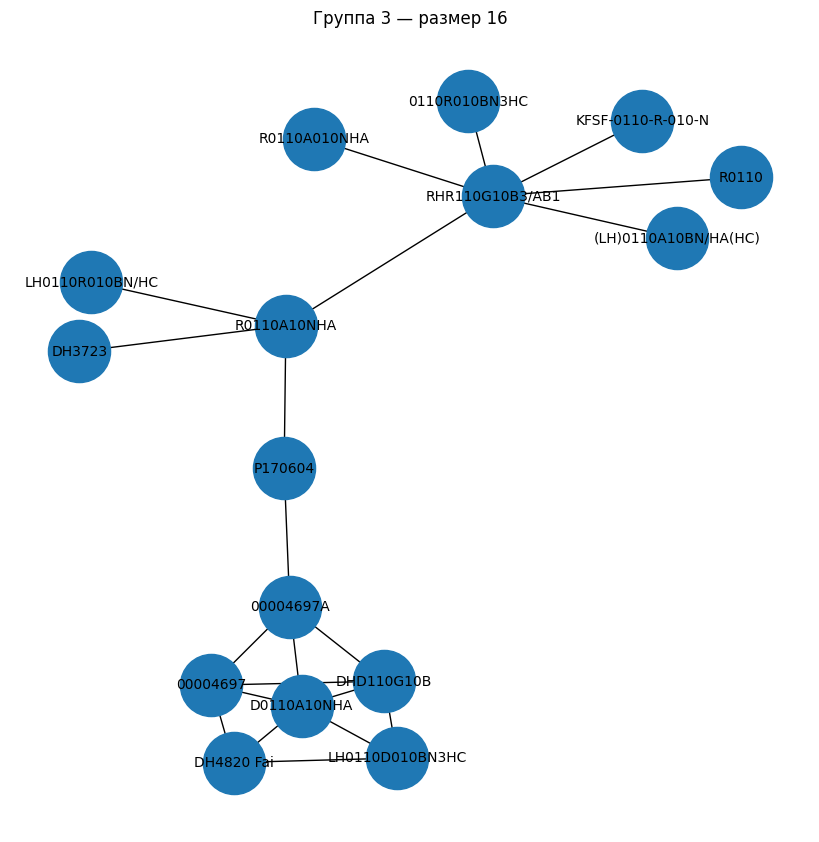

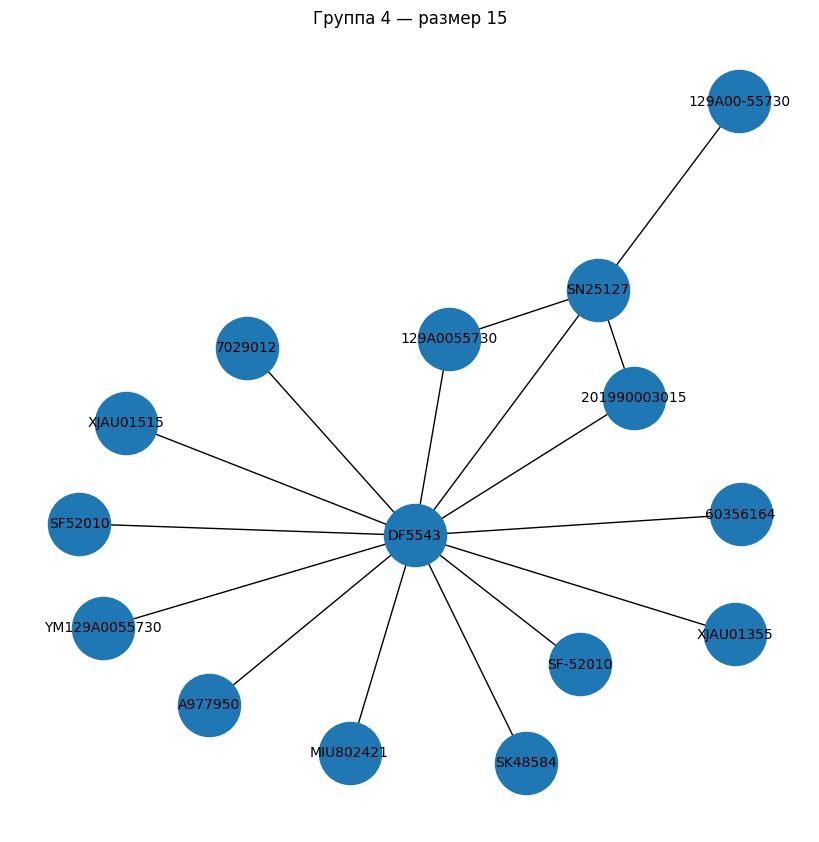

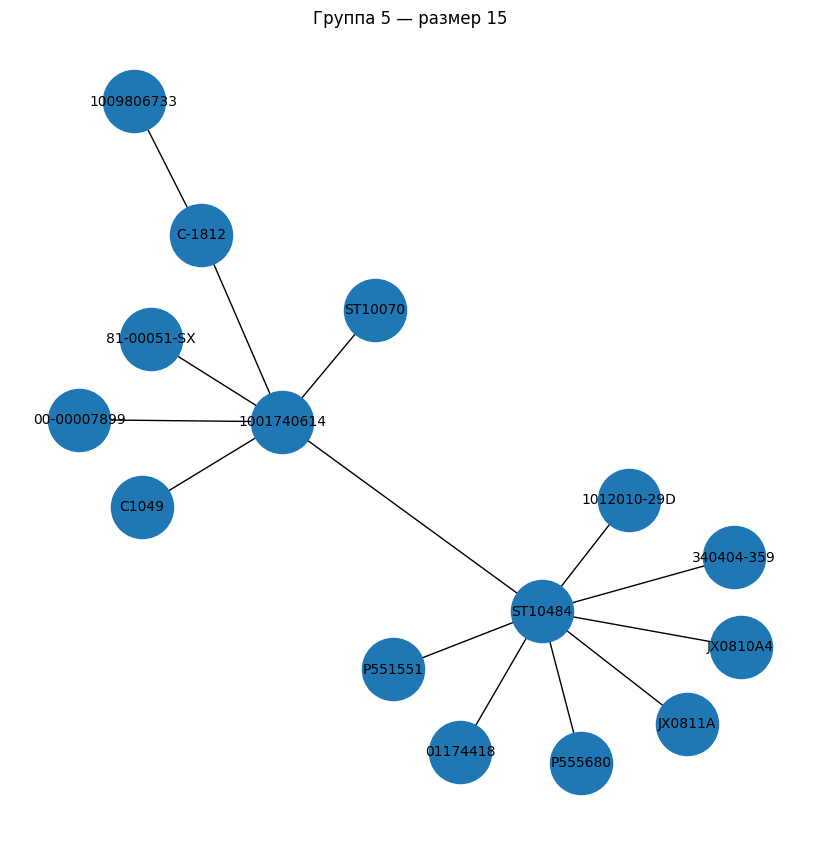

In [269]:
all_groups = []
seen = set()

for node in graph:
    if node not in seen:
        group_nodes = find_all_analogs(node, graph) | {node}
        all_groups.append(group_nodes)
        seen |= group_nodes


all_groups.sort(key=len, reverse=True)


top_n = 5
top_groups = all_groups[:top_n]

# 4️⃣ строим граф для каждой группы и рисуем
for i, group in enumerate(top_groups, 1):
    G = nx.Graph()
    for node in group:
        for neighbor in graph[node]:
            if neighbor in group:
                G.add_edge(node, neighbor)
    
    plt.figure(figsize=(8,8))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10)
    plt.title(f"Группа {i} — размер {len(group)}")
    plt.show()

In [266]:
# Фильтра
filters = df1[
    df1['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(фильтр|комплект фильтров|элемент фильтра)',
        regex=True,
        na=False
    )
]

filters.to_excel('Фильра.xlsx', index=False)
df1 = df1.drop(filters.index).reset_index(drop=True)

C:\Users\a.vorona\AppData\Local\Temp\ipykernel_16204\1579542514.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(


In [267]:
df1['Номенклатура'].value_counts()

Номенклатура
Кнопка Стоп 122514GT                                                281
Замок зажигания с ключом 84830 ZOOMLION                             279
Замок зажигания с ключом 84830/90173  4130000723001 LGMG            246
Замок зажигания с ключом IHP-30 (1020520943) 1020521389 ZOOMLION    222
Разъем НПУ в сборе с проводом Zoomlion                              131
                                                                   ... 
Джойстик 00009010                                                     1
ВПУ ZOOMLION ZS1623 1020104862 (3 кнопки над экраном)                 1
Контроллер 00007940A                                                  1
Клапан 1010308892                                                     1
Колесо в сборе 15*5  4110001269 (5 отв)                               1
Name: count, Length: 753, dtype: int64

In [268]:
df1.to_excel('leftovers.xlsx', index=False)

In [ ]:
# Замки
locks = df[
    df['Номенклатура'].str.contains('замок', case=False, na=False)
]

locks.to_excel('Замки.xlsx', index=False)

# Кнопки
buttons = df[
    df['Номенклатура'].str.contains('кнопка', case=False, na=False)
]

buttons.to_excel('Кнопки.xlsx', index=False)

# Батареи
bat = df[
    df['Номенклатура'].str.contains('батарея', case=False, na=False)
]

bat.to_excel('Батареи.xlsx', index=False)

# Обогреватели
heater = df[
    df['Номенклатура'].str.contains('|'.join(['обогреватель', 'нагреватель', 'подогреватель']), case=False, na=False)
]

heater.to_excel('Обогреватели.xlsx', index=False)

# Разъемы
socket = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(разъем)',
        regex=True,
        na=False
    )
]

socket.to_excel('Разъемы.xlsx', index=False)

# Пластины
plate = df[
    df['Номенклатура'].str.contains('пластина', case=False, na=False)
]

plate.to_excel('Пластины.xlsx', index=False)

# Масла
oil = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(масло)',
        regex=True,
        na=False
    )
]

oil.to_excel('Масла.xlsx', index=False)

# Ключи
key = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(ключ)',
        regex=True,
        na=False
    )
]

key.to_excel('Ключи.xlsx', index=False)

# Джойстики
mask_include = df['Номенклатура'].str.contains('|'.join(['джойстик', 'электроджойстик']), case=False, na=False)
mask_exclude = ~df['Номенклатура'].str.contains('рукоятка', case=False, na=False)

joystick = df[mask_include & mask_exclude]

joystick.to_excel('Джойстики.xlsx', index=False)

# Рукава
sleeve = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(рукав)',
        regex=True,
        na=False
    )
]

sleeve.to_excel('Рукава.xlsx', index=False)

# Кабели
cables = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(кабель)',
        regex=True,
        na=False
    )
]

cables.to_excel('Кабеля.xlsx', index=False)

# Тройники
splitter = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(тройник)',
        regex=True,
        na=False
    )
]

splitter.to_excel('Тройники.xlsx', index=False)

# Штуцера
fitting = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(штуцер)',
        regex=True,
        na=False
    )
]

fitting.to_excel('Штуцера.xlsx', index=False)

# ЗУ
charger = df[
    df['Номенклатура'].str.contains('|'.join(['зу', 'устройство зарядное', 'Устройство зарядное', 'Зарядное устройство', 'зарядное устройство']), case=False, na=False)
]
charger = charger[charger['Номенклатура'] != 'ЗУБР МЕХАНИК, размер L, перчатки маслобензостойкие тонкие 11276-L_z01']

charger.to_excel('ЗУ.xlsx', index=False)

# Клапаны
valve = df[
    df['Номенклатура'].str.contains('|'.join(['клапан']), case=False, na=False)
]
lst = [
    'Блок клапанов 92049371A',
    'Прокладка клапанной крышки 713115700',
    'Гидроцилиндр поворота люльки ZA20 (х8) 1010201471 без блока клапанов',
    'Соленоид электромагнитного клапана поворота колёс 92047788'
]
valve = valve[~valve['Номенклатура'].isin(lst)]
valve.to_excel('Клапана.xlsx', index=False)

# Наклейки
stickers = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(наклейка)',
        regex=True,
        na=False
    )
]
stickers.to_excel('Наклейки.xlsx', index=False)

# Тройники
splitter = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(тройник)',
        regex=True,
        na=False
    )
]

splitter.to_excel('Тройники.xlsx', index=False)

# Маячки
beacons = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(маячок)',
        regex=True,
        na=False
    )
]
beacons.to_excel('Маячки.xlsx', index=False)

# Датчики
sensors = df[
    df['Номенклатура'].str.contains('|'.join(['датчик']), case=False, na=False)
]
lst = ['Кронштейн датчика угла 93300721', 'Контакт датчика поворота колеса BA36-44 93300156A',
       'Скоба датчика BA36,BA44 50011001A', 'Контакт датчика поворота колеса BA36-44 93300156A'
]
sensors = sensors[~sensors['Номенклатура'].isin(lst)]
sensors.to_excel('Датчики.xlsx', index=False)

# Чехлы
cover = df[
    df['Номенклатура'].str.contains('|'.join(['чехол', 'термочехол']), case=False, na=False)
]
cover.to_excel('Чехлы.xlsx', index=False)

# Жгуты
harness = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(жгут)',
        regex=True,
        na=False
    )
]
harness.to_excel('Жгуты.xlsx', index=False)

# Пальцы
fingers = df[
    df['Номенклатура']
    .astype(str)
    .str.lower()
    .str.contains(
        r'^(палец)',
        regex=True,
        na=False
    )
]
fingers.to_excel('Пальцы.xlsx', index=False)

df['Номенклатура'].value_counts()[:20]

NameError: name 'df' is not defined

In [ ]:
filters_list = set(filters['Номенклатура'])
sensors_list = set(sensors['Номенклатура'])
fingers_list = set(fingers['Номенклатура'])
harness_list = set(harness['Номенклатура'])
cover_list = set(cover['Номенклатура'])
beacons_list = set(beacons['Номенклатура'])
splitter_list = set(splitter['Номенклатура'])
stickers_list = set(stickers['Номенклатура'])
valve_list = set(valve['Номенклатура'])
charger_list = set(charger['Номенклатура'])
fitting_list = set(fitting['Номенклатура'])
cables_list = set(cables['Номенклатура'])
sleeve_list = set(sleeve['Номенклатура'])
joystick_list = set(joystick['Номенклатура'])
key_list = set(key['Номенклатура'])
oil_list = set(oil['Номенклатура'])
plate_list = set(plate['Номенклатура'])
socket_list = set(socket['Номенклатура'])
heater_list = set(heater['Номенклатура'])
bat_list = set(bat['Номенклатура'])
buttons_list = set(buttons['Номенклатура'])
locks_list = set(locks['Номенклатура'])

In [ ]:
df['Категория'] = 'другое'

df.loc[df['Номенклатура'].isin(filters_list), 'Категория'] = 'фильтр'
df.loc[df['Номенклатура'].isin(sensors_list), 'Категория'] = 'датчик'
df.loc[df['Номенклатура'].isin(fingers_list), 'Категория'] = 'палец'
df.loc[df['Номенклатура'].isin(harness_list), 'Категория'] = 'жгут'
df.loc[df['Номенклатура'].isin(cover_list), 'Категория'] = 'чехол'
df.loc[df['Номенклатура'].isin(beacons_list), 'Категория'] = 'маячок'
df.loc[df['Номенклатура'].isin(splitter_list), 'Категория'] = 'тройник'
df.loc[df['Номенклатура'].isin(stickers_list), 'Категория'] = 'наклейка'
df.loc[df['Номенклатура'].isin(valve_list), 'Категория'] = 'клапан'
df.loc[df['Номенклатура'].isin(charger_list), 'Категория'] = 'зу'
df.loc[df['Номенклатура'].isin(fitting_list), 'Категория'] = 'штуцер'
df.loc[df['Номенклатура'].isin(cables_list), 'Категория'] = 'кабель'
df.loc[df['Номенклатура'].isin(sleeve_list), 'Категория'] = 'рукав'
df.loc[df['Номенклатура'].isin(joystick_list), 'Категория'] = 'джойстик'
df.loc[df['Номенклатура'].isin(key_list), 'Категория'] = 'ключ'
df.loc[df['Номенклатура'].isin(oil_list), 'Категория'] = 'масло'
df.loc[df['Номенклатура'].isin(plate_list), 'Категория'] = 'пластина'
df.loc[df['Номенклатура'].isin(socket_list), 'Категория'] = 'разъем'
df.loc[df['Номенклатура'].isin(heater_list), 'Категория'] = 'обогреватель'
df.loc[df['Номенклатура'].isin(bat_list), 'Категория'] = 'батарея'
df.loc[df['Номенклатура'].isin(buttons_list), 'Категория'] = 'кнопка'
df.loc[df['Номенклатура'].isin(locks_list), 'Категория'] = 'замок'

In [ ]:
def merge_numbers(row):
    orig = str(row['Номенклатура.Оригинальный номер'])
    ext = str(row['Номенклатура.Оригинальный номер расширенный'])
    # разбиваем по любому количеству пробелов
    ext_list = ext.split()
    if orig in ext_list:
        return ext  # уже есть — не добавляем
    else:
        return ext + ' ' + orig  # добавляем через пробел

filters['Аналоги'] = filters[filters['Номенклатура.Оригинальный номер расширенный'].notna()].apply(merge_numbers, axis=1)

In [ ]:
filters

In [ ]:
(df[df['Категория'] == 'фильтр']
 .groupby(['Год', 'Документ.Склад'])
 .size()
 .unstack())

In [ ]:
import pandas as pd
import networkx as nx

G = nx.Graph()

for idx, row in df.iterrows():
    ext = row['Номенклатура.Оригинальный номер расширенный']
    if pd.isna(ext):  # пропускаем пустые
        continue
    numbers = str(ext).split()  # приводим к строке и разбиваем по пробелу
    # соединяем все номера между собой
    for i in range(len(numbers)):
        for j in range(i+1, len(numbers)):
            G.add_edge(numbers[i], numbers[j])

# связные компоненты = группы аналогов
groups = list(nx.connected_components(G))

# создаём словарь: номер → группа
group_mapping = {}
for i, grp in enumerate(groups):
    for n in grp:
        group_mapping[n] = i

# создаём колонку с номером группы для каждой строки
def assign_group(ext):
    if pd.isna(ext):
        return None
    numbers = str(ext).split()
    # можно взять группу первой позиции
    return group_mapping.get(numbers[0], None)

df['Группа_аналогов'] = df['Номенклатура.Оригинальный номер расширенный'].apply(assign_group)

In [ ]:
df.at[255, 'Номенклатура.Оригинальный номер расширенный']

In [ ]:
df.loc[df['Группа_аналогов'] == 7, 'Номенклатура'].value_counts()

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx


sub_nodes = list(G.nodes)[:100]
H = G.subgraph(sub_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(H, seed=42) 
nx.draw(H, pos, with_labels=True, node_color='skyblue', node_size=800, font_size=10, edge_color='gray')
plt.title("Подграф первых 50 номеров запчастей")
plt.show()